# Isovalue Specialist: Histogram Bands + Derived Opacity Ramp

Tests `visualization_orchestrator/specialists/isovalue_adapter.py` directly -- no planner, no camera specialist, no `VisualizationOrchestrator` wrapper -- so you can inspect each step in isolation:

1. `compute_histogram_bands` -- segment the volume's intensity histogram into material bands (deterministic).
2. Render one cheap preview per band (deterministic).
3. `run_isovalue_band_selection` -- one LLM call picks which band matches a goal, then deterministically derives and applies an opacity ramp from that band's own range.

Uses `data/vis_male_128x256x256_uint8.raw`, which segments cleanly into 3 bands (background / soft tissue / bone) -- see the README's "Isovalue specialist" section for why `data/skull_256x256x256_uint8.raw` does *not* currently work well here (its histogram has no distinct bone peak).

## Setup

Scene initialized. Isovalue=40, dims=(256, 256, 256).


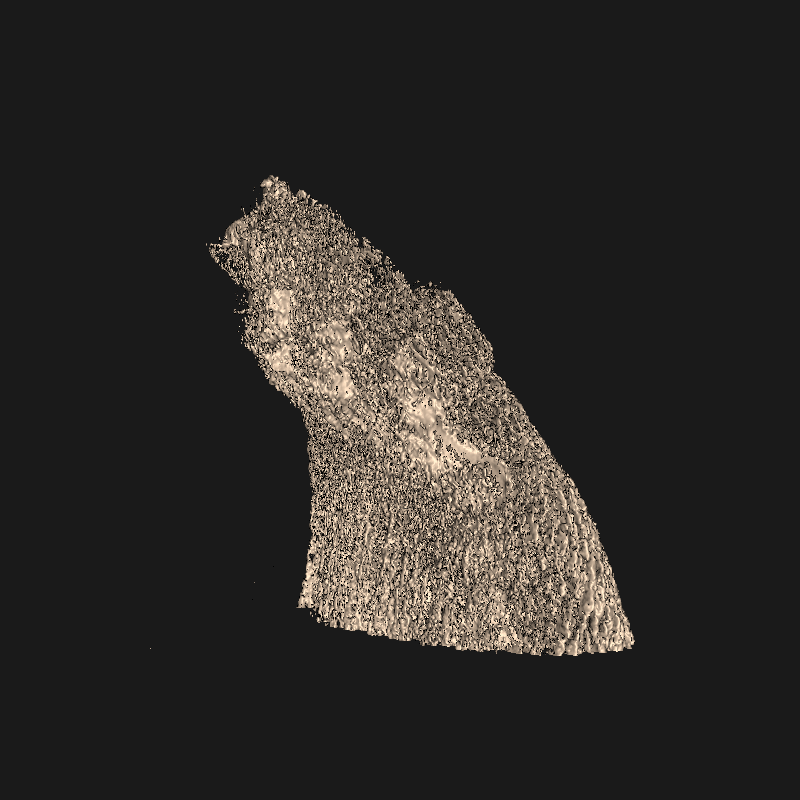

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from camera_reasoning.session import CameraReasoningSession
from visualization_orchestrator.specialists.isovalue_adapter import (
    BAND_LABEL_PREFIX,
    build_opacity_ramp_for_band,
    compute_histogram_bands,
    render_isovalue_candidates,
    run_isovalue_band_selection,
)

DATASET_PATH = "../data/vis_male_128x256x256_uint8.raw"
DIMENSIONS = (128, 256, 256)

session = CameraReasoningSession(
    raw_path=DATASET_PATH,
    dimensions=DIMENSIONS,
    isovalue=40,
    output_dir="../output/isovalue_band_demo",
)
session.initialize()
display(Image(filename=session.render_and_save()))

## Step 1: histogram bands (deterministic, no LLM)

Each band is a `[low, high)` intensity range with one `peak`. `voxel_fraction` is how much of the volume falls in that band -- should sum to ~1.0.

In [2]:
bands = compute_histogram_bands(DATASET_PATH)
for b in bands:
    print(f"[{b['low']:3d}-{b['high']:3d})  peak={b['peak']:3d}  voxel_fraction={b['voxel_fraction']:.4f}")
print(f"total voxel_fraction: {sum(b['voxel_fraction'] for b in bands):.6f}")

[  0-  6)  peak=  4  voxel_fraction=0.7208
[  6-256)  peak= 32  voxel_fraction=0.2792
total voxel_fraction: 1.000000


### Visualize the histogram with band boundaries overlaid

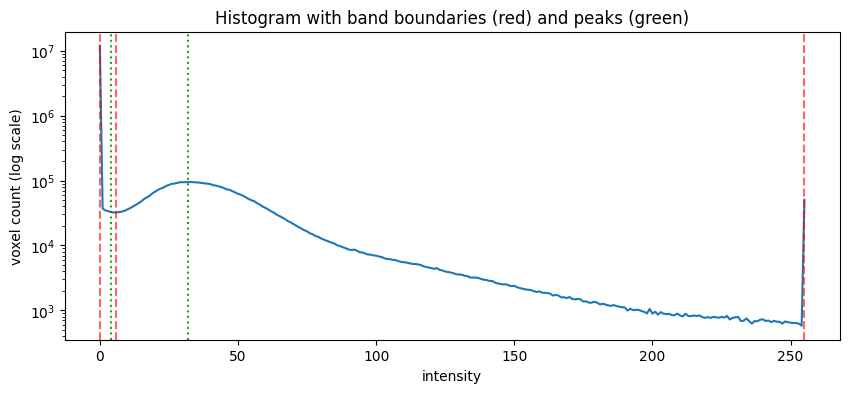

In [3]:
intensities = np.fromfile(DATASET_PATH, dtype=np.uint8)
hist, edges = np.histogram(intensities, bins=256, range=(0, 256))

plt.figure(figsize=(10, 4))
plt.plot(hist)
for b in bands:
    plt.axvline(b["low"], color="red", linestyle="--", alpha=0.6)
    plt.axvline(b["peak"], color="green", linestyle=":", alpha=0.8)
plt.axvline(bands[-1]["high"] - 1, color="red", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.xlabel("intensity")
plt.ylabel("voxel count (log scale)")
plt.title("Histogram with band boundaries (red) and peaks (green)")
plt.show()

## Step 2: per-band preview renders (deterministic, no LLM)

One preview per band, rendered as a plain isosurface at that band's peak -- this is what the LLM is shown when picking a band. `multi_angle=False` here just to keep this cheap/fast; the real pipeline defaults to a 6-angle tiled grid per band.

BAND_0_6  (preview at peak=4)


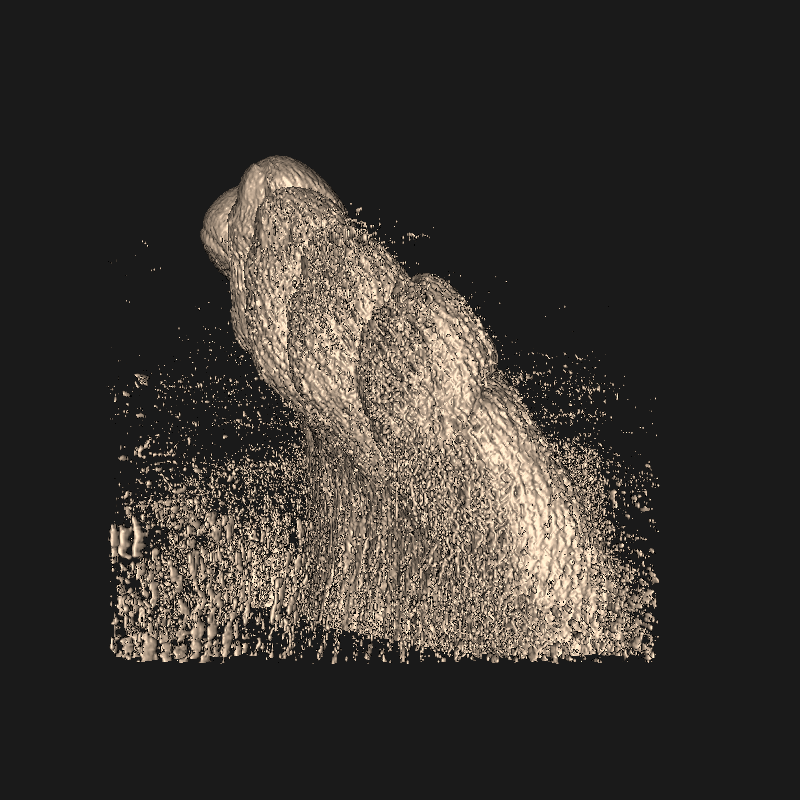

BAND_6_256  (preview at peak=32)


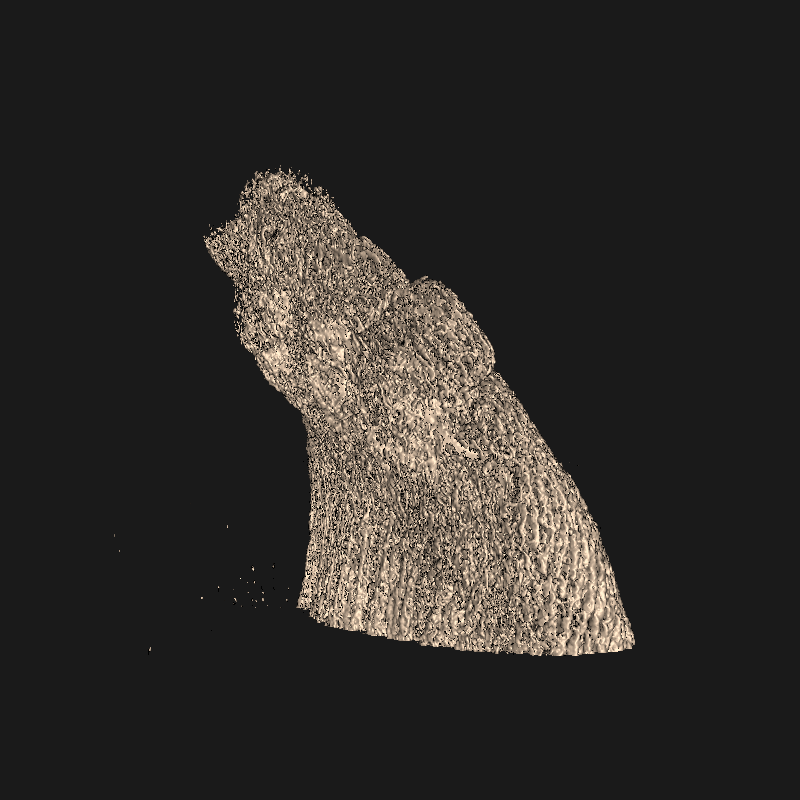

In [4]:
peaks = [b["peak"] for b in bands]
previews = render_isovalue_candidates(session, peaks, "../output/isovalue_band_demo/previews", multi_angle=False)

for band, (peak, path) in zip(bands, previews):
    print(f"{BAND_LABEL_PREFIX}{band['low']}_{band['high']}  (preview at peak={peak})")
    display(Image(filename=path, width=300))

## Step 3: full band selection (ONE real LLM call)

Requires `OPENAI_API_KEY`. Edit `GOAL` below and re-run to try different instructions -- e.g. `"show the bone"`, `"show the soft tissue"`, `"reduce the noise"`.

selected_band_label: BAND_6_256
converged: True
reasoning: BAND_6_256 is the best match for showing bone structure. While both bands display the foot bones, BAND_6_256 presents a much cleaner visualization with minimal noise and fragmentation across all camera angles. BAND_0_6 shows excessive scattered particles and surface artifacts that would interfere with clear bone visualization. BAND_6_256 meets both success criteria: bone structure is clearly visible and there is minimal noise or fragmentation.

  [BAND_0_6] satisfies_goal=False  Shows a foot with clearly visible bone structure including toes and metatarsals. However, there is significant noise and fragmentation visible in multiple views, particularly evident as scattered particles around the main structure in the front, right, back, left, and bottom views. The surface appears rough with many artifacts.
  [BAND_6_256] satisfies_goal=True  Shows the same foot bone structure with toes and metatarsals clearly visible across all vie

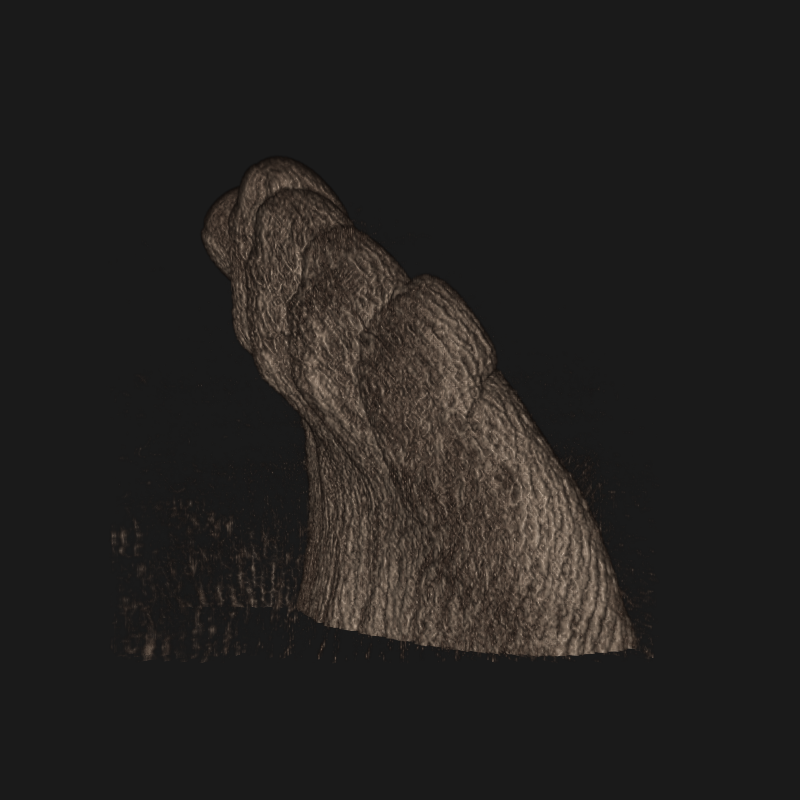

In [5]:
GOAL = "show the bone"
SUCCESS_CRITERIA = ["bone structure is clearly visible", "minimal noise or fragmentation"]

result = run_isovalue_band_selection(session, goal=GOAL, success_criteria=SUCCESS_CRITERIA)

print(f"selected_band_label: {result['selected_band_label']}")
print(f"converged: {result['converged']}")
print(f"reasoning: {result['reasoning']}")
print()
for entry in result["band_evaluation"]:
    print(f"  [{entry.get('band')}] satisfies_goal={entry.get('satisfies_goal')}  {entry.get('observation')}")

display(Image(filename=result["final_image_path"]))

## Step 4: inspect the derived opacity ramp (deterministic, no LLM)

The selected band's own `[low, high, peak]` -- not hand-tuned constants -- determine these control points. See `build_opacity_ramp_for_band` in `isovalue_adapter.py`.

In [ ]:
print("opacity_points:", result["final_opacity_points"])
print("color_points:", result["final_color_points"])

if result["final_opacity_points"]:
    xs, ys = zip(*result["final_opacity_points"])
    plt.figure(figsize=(8, 3))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("intensity")
    plt.ylabel("opacity")
    plt.title("Applied opacity ramp")
    plt.ylim(0, 1)
    plt.show()

## Try a different band directly (no LLM, no goal -- just pick one from Step 1's list by index)

In [ ]:
BAND_INDEX = 1  # 0=background, 1=soft tissue, 2=bone for vis_male's 3 bands

chosen_band = bands[BAND_INDEX]
opacity_points, color_points = build_opacity_ramp_for_band(chosen_band)
session.set_transfer_function(opacity_points, color_points)
display(Image(filename=session.render_and_save()))